# Variance / Concentration Alignment: LLM Ensemble vs. Human Annotators

Tests whether the **spread / concentration** of LLM-ensemble scores for hedge expressions
agrees with that of human annotators. Complements the central-tendency analysis in
`paper_materials/fig_verify_llm_ensemble_stats.ipynb`.

## Tests performed

### A. Expression-level variance correlation
- Spearman / Pearson / Kendall rank correlations between per-expression σ (LLM) and σ (human)
- Same for Coefficient of Variation (CV = σ/μ) — normalises for mean-level differences
- Bland–Altman limits-of-agreement on σ values
- Wilcoxon signed-rank test: is LLM σ systematically different from human σ?

### B. Per-expression scale equality (FDR-corrected)
- **Levene's test** (absolute deviations from median) — robust to non-normality
- **Fligner–Killeen test** — fully non-parametric, rank-based scale test
- **Ansari–Bradley test** — non-parametric, tests for scale shift with no location assumption
- Benjamini–Hochberg FDR correction applied to each battery

### C. Beta-distribution concentration
- Fit a Beta(α, β) to each expression's score list via MLE
- Concentration κ = α + β is inversely proportional to variance
- Test rank correlation of κ_LLM vs κ_human; Wilcoxon for systematic concentration difference

### D. Variance-ratio analysis
- Per-expression ratio σ²_LLM / σ²_human
- Global F-test on pooled variances
- Permutation test for overall variance ratio

In [1]:
import sys, os, ast, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import (
    spearmanr, pearsonr, kendalltau,
    wilcoxon, levene, fligner, ansari,
    false_discovery_control,
    beta as beta_dist,
)
from scipy.special import gammaln

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── paths ─────────────────────────────────────────────────────────────────────
REPO_DIR    = os.path.abspath(os.path.join(os.getcwd(), "../.."))
LEXICON_DIR = os.path.join(REPO_DIR, "linguistic_confidence_lexicon")
PAPER_DIR   = os.path.join(REPO_DIR, "paper_materials")
SAVE_DIR    = os.getcwd()
FIG_DIR     = os.path.join(SAVE_DIR, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

np.random.seed(42)
rng = np.random.default_rng(42)
print(f"Repo : {REPO_DIR}")
print(f"Figs : {FIG_DIR}")

Repo : /home/ivan/lm-confidence-evaluation-harness
Figs : /home/ivan/lm-confidence-evaluation-harness/rebuttal/llm-human-alignment-var/figs


## 1. Load Data

In [2]:
lexicon_df = pd.read_csv(os.path.join(LEXICON_DIR, "distilled_hedging_lexicon.csv"))
lexicon_df["human_scores"] = lexicon_df["normalized_confidence_scores"].apply(ast.literal_eval)

with open(os.path.join(PAPER_DIR, "verify_llm_ensemble_scores.pkl"), "rb") as f:
    llm_scores_collection = pickle.load(f)

assert len(llm_scores_collection) == len(lexicon_df)
lexicon_df["llm_scores"] = llm_scores_collection

print(f"Loaded {len(lexicon_df):,} items, "
      f"{lexicon_df['extracted_hedging_expression'].nunique()} unique expressions")
lexicon_df[["uncertainty_expression", "extracted_hedging_expression",
            "human_scores", "llm_scores"]].head(3)

Loaded 1,622 items, 159 unique expressions


,uncertainty_expression,extracted_hedging_expression,human_scores,llm_scores
0,All signs point to Linus Pauling.,point to,"[0.73, 0.71, 0.62]","[0.85, 0.85, 0.75, 0.98, 0.92, 0.95, 0.8, 0.95..."
1,I believe Airrack hosted the 12th Streamy Awards.,I believe,"[0.75, 0.79, 0.67]","[0.55, 0.45, 0.75, 0.52, 0.55, 0.71, 0.85, 0.9..."
2,The municipality seems to have been establishe...,seems to,"[0.75, 0.77, 0.7]","[0.85, 0.85, 0.65, 0.78, 0.76, 0.49, 0.85, 0.7..."


## 2. Aggregate Per-Expression Statistics (mean, std, CV)

In [3]:
def pool(series_of_lists):
    return [s for lst in series_of_lists for s in lst]

grouped = (
    lexicon_df
    .groupby("extracted_hedging_expression", sort=False)
    .agg(
        llm_scores   = ("llm_scores",   pool),
        human_scores = ("human_scores", pool),
        n_items      = ("uncertainty_expression", "count"),
    )
    .reset_index()
    .rename(columns={"extracted_hedging_expression": "expression"})
)

for col in ["llm", "human"]:
    sc = f"{col}_scores"
    grouped[f"{col}_mean"]   = grouped[sc].apply(np.mean)
    grouped[f"{col}_median"] = grouped[sc].apply(np.median)
    grouped[f"{col}_std"]    = grouped[sc].apply(lambda v: np.std(v, ddof=1))
    grouped[f"{col}_var"]    = grouped[sc].apply(lambda v: np.var(v, ddof=1))
    grouped[f"{col}_n"]      = grouped[sc].apply(len)
    # Coefficient of Variation; guard against mean ≈ 0
    grouped[f"{col}_cv"]     = grouped[f"{col}_std"] / grouped[f"{col}_mean"].replace(0, np.nan)

grouped = grouped.dropna(subset=["llm_std", "human_std"])
# Keep only expressions with at least 3 scores in each pool
grouped = grouped[(grouped["llm_n"] >= 3) & (grouped["human_n"] >= 3)]

print(f"Expressions retained: {len(grouped)}")
print(f"\nLLM   std  — median={grouped['llm_std'].median():.4f}, "
      f"mean={grouped['llm_std'].mean():.4f}")
print(f"Human std  — median={grouped['human_std'].median():.4f}, "
      f"mean={grouped['human_std'].mean():.4f}")

grouped[["expression","n_items",
         "llm_std","human_std",
         "llm_cv", "human_cv"]].head(6)

Expressions retained: 159

LLM   std  — median=0.1194, mean=0.1226
Human std  — median=0.0761, mean=0.1000


,expression,n_items,llm_std,human_std,llm_cv,human_cv
0,point to,11,0.062841,0.050883,0.068201,0.070240
1,I believe,120,0.145261,0.118108,0.184271,0.180398
2,seems to,22,0.132797,0.067092,0.167914,0.098061
3,it seems to me,7,0.141942,0.072972,0.206369,0.106360
4,might be,16,0.148941,0.095157,0.268116,0.308715
5,I am pretty sure,27,0.075229,0.053230,0.085430,0.075936


---
## A. Expression-Level Variance Correlation

### A1. Rank / Linear Correlations — σ and CV

In [4]:
def corr_block(a, b, label):
    sp_r, sp_p   = spearmanr(a, b)
    pe_r, pe_p   = pearsonr(a, b)
    kt_t, kt_p   = kendalltau(a, b)
    rows = [
        {"Measure": label, "Test": "Spearman ρ",  "Statistic": sp_r, "p-value": sp_p},
        {"Measure": label, "Test": "Pearson r",   "Statistic": pe_r, "p-value": pe_p},
        {"Measure": label, "Test": "Kendall τ",   "Statistic": kt_t, "p-value": kt_p},
    ]
    return rows, sp_r, sp_p, pe_r, pe_p, kt_t, kt_p

std_rows, sp_r_std, sp_p_std, pe_r_std, pe_p_std, kt_t_std, kt_p_std = \
    corr_block(grouped["llm_std"].values, grouped["human_std"].values, "σ (std dev)")

cv_mask  = grouped["llm_cv"].notna() & grouped["human_cv"].notna()
cv_rows, sp_r_cv, sp_p_cv, pe_r_cv, pe_p_cv, kt_t_cv, kt_p_cv = \
    corr_block(grouped.loc[cv_mask, "llm_cv"].values,
               grouped.loc[cv_mask, "human_cv"].values, "CV (σ/μ)")

corr_df = pd.DataFrame(std_rows + cv_rows)
corr_df["Significant (α=0.05)"] = corr_df["p-value"] < 0.05
corr_df = corr_df.round(5)
print("=== Correlation of per-expression spread ===\n")
print(corr_df.to_string(index=False))

=== Correlation of per-expression spread ===

    Measure       Test  Statistic  p-value  Significant (α=0.05)
σ (std dev) Spearman ρ    0.55599      0.0                  True
σ (std dev)  Pearson r    0.69746      0.0                  True
σ (std dev)  Kendall τ    0.40779      0.0                  True
   CV (σ/μ) Spearman ρ    0.72112      0.0                  True
   CV (σ/μ)  Pearson r    0.61107      0.0                  True
   CV (σ/μ)  Kendall τ    0.54590      0.0                  True


### A2. Scatter Plots — σ vs σ, CV vs CV

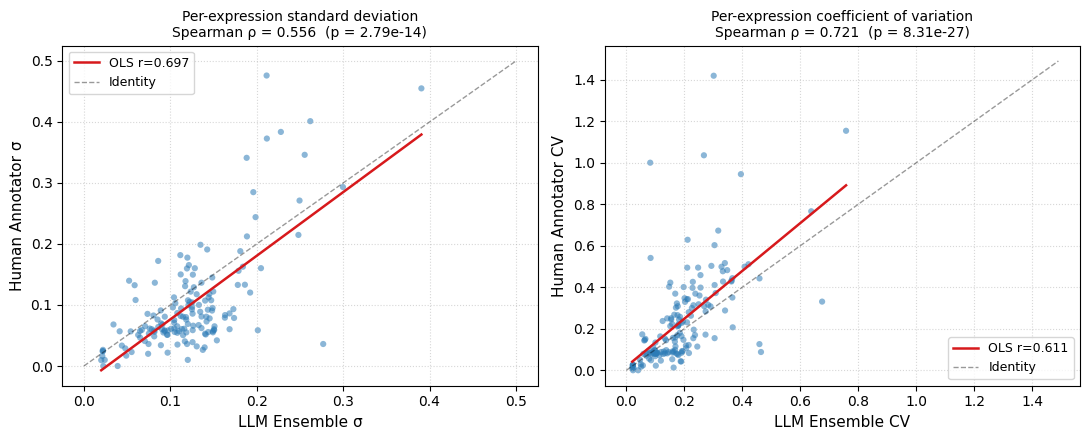

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, xcol, ycol, xlabel, ylabel, title, sp_r, sp_p in [
    (axes[0], "llm_std", "human_std",
     "LLM Ensemble σ", "Human Annotator σ",
     "Per-expression standard deviation",
     sp_r_std, sp_p_std),
    (axes[1], "llm_cv",  "human_cv",
     "LLM Ensemble CV", "Human Annotator CV",
     "Per-expression coefficient of variation",
     sp_r_cv, sp_p_cv),
]:
    xv = grouped[xcol].dropna()
    yv = grouped[ycol].dropna()
    idx = xv.index.intersection(yv.index)
    xv, yv = xv[idx].values, yv[idx].values

    ax.scatter(xv, yv, s=20, alpha=0.55, color="#2c7bb6", edgecolors="none")
    slope, intercept, r_val, p_val, _ = stats.linregress(xv, yv)
    xl = np.linspace(xv.min(), xv.max(), 200)
    ax.plot(xl, slope*xl + intercept, color="#d7191c", lw=1.8,
            label=f"OLS r={r_val:.3f}")
    lim = max(xv.max(), yv.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.4, label="Identity")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f"{title}\nSpearman ρ = {sp_r:.3f}  (p = {sp_p:.2e})", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "variance_scatter_std_cv.pdf"), bbox_inches="tight", dpi=300)
plt.show()

### A3. Bland–Altman on Standard Deviations

=== Bland–Altman on per-expression σ ===
  Mean bias (LLM σ − Human σ) : +0.02266
  95% LoA                     : [-0.09531, +0.14064]
  % within LoA                : 95.6%


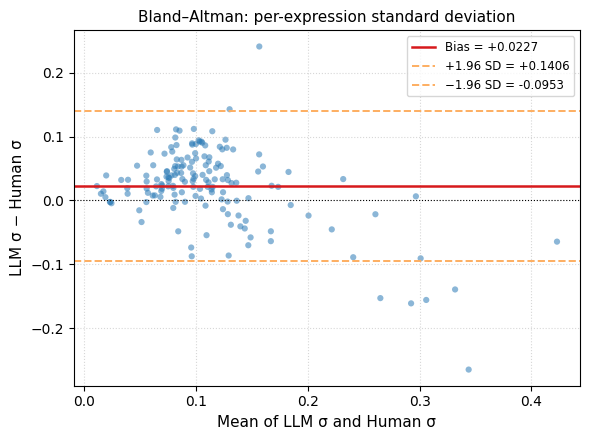

In [6]:
diff_std  = grouped["llm_std"].values - grouped["human_std"].values
mean_std  = (grouped["llm_std"].values + grouped["human_std"].values) / 2

bias_std  = diff_std.mean()
sd_std    = diff_std.std(ddof=1)
loa_lo    = bias_std - 1.96 * sd_std
loa_hi    = bias_std + 1.96 * sd_std
pct_in    = (np.abs(diff_std) <= 1.96 * sd_std).mean() * 100

print("=== Bland–Altman on per-expression σ ===")
print(f"  Mean bias (LLM σ − Human σ) : {bias_std:+.5f}")
print(f"  95% LoA                     : [{loa_lo:+.5f}, {loa_hi:+.5f}]")
print(f"  % within LoA                : {pct_in:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(mean_std, diff_std, s=20, alpha=0.55, color="#2c7bb6", edgecolors="none")
ax.axhline(bias_std, color="#d7191c", lw=1.8, label=f"Bias = {bias_std:+.4f}")
ax.axhline(loa_hi,   color="#fdae61", lw=1.4, ls="--",
           label=f"+1.96 SD = {loa_hi:+.4f}")
ax.axhline(loa_lo,   color="#fdae61", lw=1.4, ls="--",
           label=f"−1.96 SD = {loa_lo:+.4f}")
ax.axhline(0, color="black", lw=0.8, ls=":")
ax.set_xlabel("Mean of LLM σ and Human σ", fontsize=11)
ax.set_ylabel("LLM σ − Human σ", fontsize=11)
ax.set_title("Bland–Altman: per-expression standard deviation", fontsize=11)
ax.legend(fontsize=8.5)
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "bland_altman_std.pdf"), bbox_inches="tight", dpi=300)
plt.show()

### A4. Wilcoxon Signed-Rank: Systematic σ Difference

In [7]:
wsr_stat, wsr_p = wilcoxon(
    grouped["llm_std"].values,
    grouped["human_std"].values,
    alternative="two-sided", zero_method="wilcox"
)
n_expr = len(grouped)
# approximate Z for effect size
Z_approx   = stats.norm.ppf(wsr_p / 2) if wsr_p > 0 else -30
effect_r   = abs(Z_approx) / np.sqrt(n_expr)

print("=== Wilcoxon Signed-Rank: per-expression σ ===")
print(f"  H₀: median(LLM σ − Human σ) = 0")
print(f"  W  = {wsr_stat:.1f},  p = {wsr_p:.4e}")
print(f"  Effect size r ≈ {effect_r:.4f}")
print(f"  Reject H₀: {wsr_p < 0.05}")
print()

# Repeat on CV
cv_a = grouped.loc[cv_mask, "llm_cv"].values
cv_b = grouped.loc[cv_mask, "human_cv"].values
wsr_cv_stat, wsr_cv_p = wilcoxon(cv_a, cv_b, alternative="two-sided", zero_method="wilcox")
print("=== Wilcoxon Signed-Rank: per-expression CV ===")
print(f"  W  = {wsr_cv_stat:.1f},  p = {wsr_cv_p:.4e}")
print(f"  Reject H₀: {wsr_cv_p < 0.05}")

=== Wilcoxon Signed-Rank: per-expression σ ===
  H₀: median(LLM σ − Human σ) = 0
  W  = 3027.0,  p = 9.9401e-09
  Effect size r ≈ 0.4546
  Reject H₀: True

=== Wilcoxon Signed-Rank: per-expression CV ===
  W  = 4746.0,  p = 5.5102e-03
  Reject H₀: True


---
## B. Per-Expression Scale Equality (FDR-Corrected)

For each expression, three non-parametric scale tests compare LLM and human score
distributions **after removing location effects**:

| Test | Null hypothesis | Location removal |
|------|----------------|------------------|
| Levene (median) | Equal spread | Subtract group median |
| Fligner–Killeen | Equal spread | Subtract group median, rank absolute deviations |
| Ansari–Bradley | Equal scale parameter | Subtracts group medians before ranking |

BH FDR correction at α = 0.05.

In [8]:
rows = []
for _, row in grouped.iterrows():
    llm_s   = np.array(row["llm_scores"])
    human_s = np.array(row["human_scores"])
    if len(llm_s) < 3 or len(human_s) < 3:
        continue

    lev_stat, lev_p   = levene(llm_s, human_s, center="median")
    flg_stat, flg_p   = fligner(llm_s, human_s, center="median")
    ab_stat,  ab_p    = ansari(llm_s, human_s)

    var_ratio = np.var(llm_s, ddof=1) / np.var(human_s, ddof=1) \
                if np.var(human_s, ddof=1) > 0 else np.nan

    rows.append({
        "expression" : row["expression"],
        "n_llm"      : len(llm_s),
        "n_human"    : len(human_s),
        "llm_std"    : row["llm_std"],
        "human_std"  : row["human_std"],
        "var_ratio"  : var_ratio,
        "levene_stat": lev_stat, "levene_p"  : lev_p,
        "fligner_stat": flg_stat,"fligner_p" : flg_p,
        "ansari_stat": ab_stat,  "ansari_p"  : ab_p,
    })

per_expr = pd.DataFrame(rows)

# BH-FDR correction
for col in ["levene_p", "fligner_p", "ansari_p"]:
    per_expr[col + "_fdr"] = false_discovery_control(per_expr[col].values, method="bh")

n_total  = len(per_expr)
for test in ["levene", "fligner", "ansari"]:
    n_sig = (per_expr[f"{test}_p_fdr"] < 0.05).sum()
    print(f"{test.capitalize():12s}: {n_sig:3d}/{n_total} "
          f"({n_sig/n_total*100:.1f}%) significantly different variance  (BH α=0.05)")

print(f"\nMedian variance ratio (LLM σ² / Human σ²): {per_expr['var_ratio'].median():.4f}")
print(f"Mean   variance ratio                      : {per_expr['var_ratio'].mean():.4f}")

Levene      :  32/159 (20.1%) significantly different variance  (BH α=0.05)
Fligner     :  32/159 (20.1%) significantly different variance  (BH α=0.05)
Ansari      :  53/159 (33.3%) significantly different variance  (BH α=0.05)

Median variance ratio (LLM σ² / Human σ²): 1.8970
Mean   variance ratio                      : 522987589404989217820377088.0000


### B2. Visualise Scale Test p-value Distributions

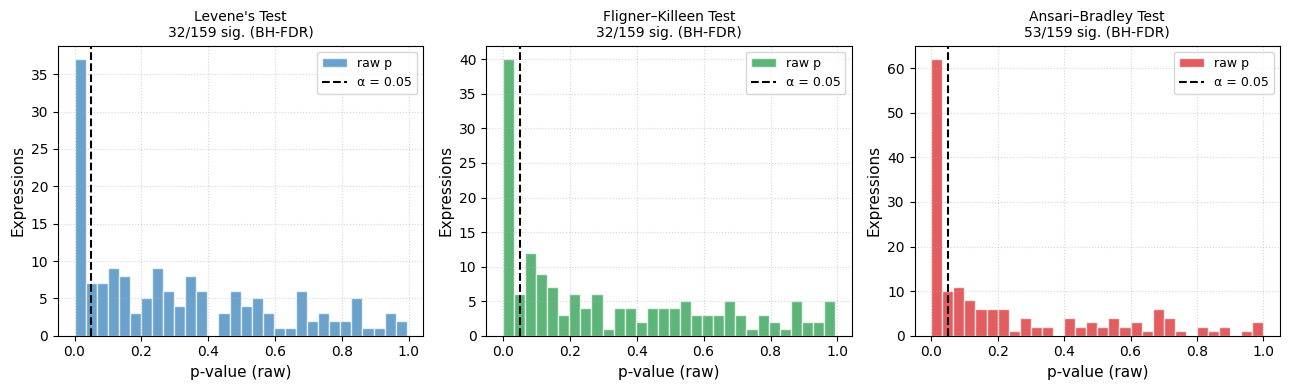

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors  = ["#2c7bb6", "#1a9641", "#d7191c"]
tests   = [("levene_p",  "Levene's Test"),
           ("fligner_p", "Fligner–Killeen Test"),
           ("ansari_p",  "Ansari–Bradley Test")]

for ax, (pcol, title), color in zip(axes, tests, colors):
    ax.hist(per_expr[pcol], bins=30, color=color, alpha=0.7, edgecolor="white", label="raw p")
    fdr_col = pcol + "_fdr"
    n_sig = (per_expr[fdr_col] < 0.05).sum()
    ax.axvline(0.05, color="black", lw=1.5, ls="--", label="α = 0.05")
    ax.set_xlabel("p-value (raw)", fontsize=11)
    ax.set_ylabel("Expressions", fontsize=11)
    ax.set_title(f"{title}\n{n_sig}/{n_total} sig. (BH-FDR)", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "scale_test_pvals.pdf"), bbox_inches="tight", dpi=300)
plt.show()

### B3. Variance Ratio Distribution

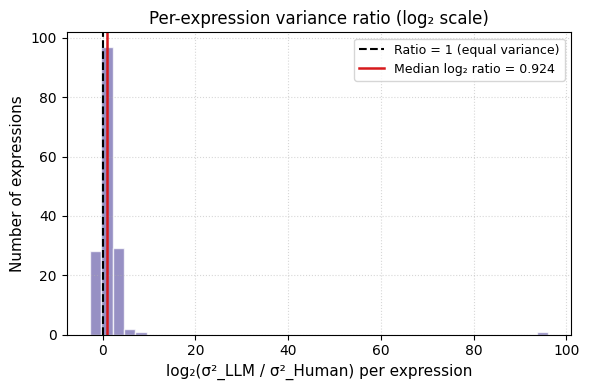

Expressions with variance ratio within [0.5, 2.0]: 43.7%


In [10]:
vr = per_expr["var_ratio"].dropna()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log2(vr), bins=40, color="#756bb1", alpha=0.75, edgecolor="white")
ax.axvline(0, color="black", lw=1.5, ls="--", label="Ratio = 1 (equal variance)")
ax.axvline(np.log2(vr.median()), color="#d7191c", lw=1.8,
           label=f"Median log₂ ratio = {np.log2(vr.median()):.3f}")
ax.set_xlabel("log₂(σ²_LLM / σ²_Human) per expression", fontsize=11)
ax.set_ylabel("Number of expressions", fontsize=11)
ax.set_title("Per-expression variance ratio (log₂ scale)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "variance_ratio_hist.pdf"), bbox_inches="tight", dpi=300)
plt.show()

pct_within2x = ((vr >= 0.5) & (vr <= 2.0)).mean() * 100
print(f"Expressions with variance ratio within [0.5, 2.0]: {pct_within2x:.1f}%")

---
## C. Beta-Distribution Concentration

Each expression's score list lives on [0, 1]. We fit a **Beta(α, β)** via MLE (Method of
Moments as warm-start, then `scipy.stats.beta.fit`). The **concentration** parameter
κ = α + β is inversely related to variance:

$$\text{Var} = \frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)} \approx \frac{1}{4(\kappa+1)}$$

High κ → tightly concentrated scores; low κ → diffuse scores.

In [11]:
def fit_beta_concentration(scores, eps=1e-4):
    """MLE Beta fit; returns (alpha, beta, kappa). Returns nan on failure."""
    s = np.array(scores, dtype=float)
    # clip to open interval
    s = np.clip(s, eps, 1 - eps)
    if len(s) < 3 or s.var() == 0:
        return np.nan, np.nan, np.nan
    # MoM warm-start
    mu  = s.mean(); v = s.var(ddof=1)
    kap0 = max(mu*(1-mu)/v - 1, 0.1)
    a0, b0 = mu*kap0, (1-mu)*kap0
    try:
        a, b, _, _ = beta_dist.fit(s, a0, b0, floc=0, fscale=1)
        return a, b, a + b
    except Exception:
        return np.nan, np.nan, np.nan


kappa_rows = []
for _, row in grouped.iterrows():
    llm_a, llm_b, llm_k   = fit_beta_concentration(row["llm_scores"])
    hum_a, hum_b, hum_k   = fit_beta_concentration(row["human_scores"])
    kappa_rows.append({
        "expression" : row["expression"],
        "llm_kappa"  : llm_k,
        "human_kappa": hum_k,
        "llm_alpha"  : llm_a, "llm_beta" : llm_b,
        "hum_alpha"  : hum_a, "hum_beta" : hum_b,
    })

kappa_df = pd.DataFrame(kappa_rows).dropna(subset=["llm_kappa", "human_kappa"])
print(f"Expressions with valid Beta fits: {len(kappa_df)} / {len(grouped)}")
print(f"\nLLM   κ — median={kappa_df['llm_kappa'].median():.2f}, "
      f"mean={kappa_df['llm_kappa'].mean():.2f}")
print(f"Human κ — median={kappa_df['human_kappa'].median():.2f}, "
      f"mean={kappa_df['human_kappa'].mean():.2f}")

kappa_df[["expression","llm_kappa","human_kappa","llm_alpha","llm_beta","hum_alpha","hum_beta"]].head(6)

Expressions with valid Beta fits: 159 / 159

LLM   κ — median=11.10, mean=15.50
Human κ — median=35.19, mean=24287861753938524389274288128.00


,expression,llm_kappa,human_kappa,llm_alpha,llm_beta,hum_alpha,hum_beta
0,point to,13.344839,79.310339,12.306391,1.038448,57.452196,21.858143
1,I believe,5.389007,16.454335,4.276382,1.112625,10.709073,5.745262
2,seems to,8.597127,47.110829,6.790901,1.806226,32.239998,14.870831
3,it seems to me,9.884468,40.894294,6.782499,3.101969,28.064728,12.829567
4,might be,9.394651,21.618422,5.223175,4.171476,6.647686,14.970736
5,I am pretty sure,18.158710,72.440879,15.989476,2.169234,50.786138,21.654741


### C2. Rank Correlation of κ and Wilcoxon for Systematic Difference

In [12]:
k_llm   = kappa_df["llm_kappa"].values
k_human = kappa_df["human_kappa"].values

sp_k, sp_pk   = spearmanr(k_llm, k_human)
pe_k, pe_pk   = pearsonr(k_llm, k_human)
kt_k, kt_pk   = kendalltau(k_llm, k_human)
wsr_k, wsr_pk = wilcoxon(k_llm, k_human, alternative="two-sided", zero_method="wilcox")

print("=== Beta Concentration κ = α + β ===")
print(f"  Spearman ρ  = {sp_k:.4f}  (p = {sp_pk:.3e})")
print(f"  Pearson  r  = {pe_k:.4f}  (p = {pe_pk:.3e})")
print(f"  Kendall  τ  = {kt_k:.4f}  (p = {kt_pk:.3e})")
print()
print("=== Wilcoxon on κ (H₀: no systematic concentration difference) ===")
print(f"  W = {wsr_k:.1f},  p = {wsr_pk:.4e}")
print(f"  Reject H₀: {wsr_pk < 0.05}")
print(f"  Median κ_LLM − κ_Human = {np.median(k_llm - k_human):.3f}")

=== Beta Concentration κ = α + β ===
  Spearman ρ  = 0.3581  (p = 3.574e-06)
  Pearson  r  = -0.0174  (p = 8.276e-01)
  Kendall  τ  = 0.2529  (p = 2.226e-06)

=== Wilcoxon on κ (H₀: no systematic concentration difference) ===
  W = 1250.0,  p = 1.5272e-18
  Reject H₀: True
  Median κ_LLM − κ_Human = -16.786


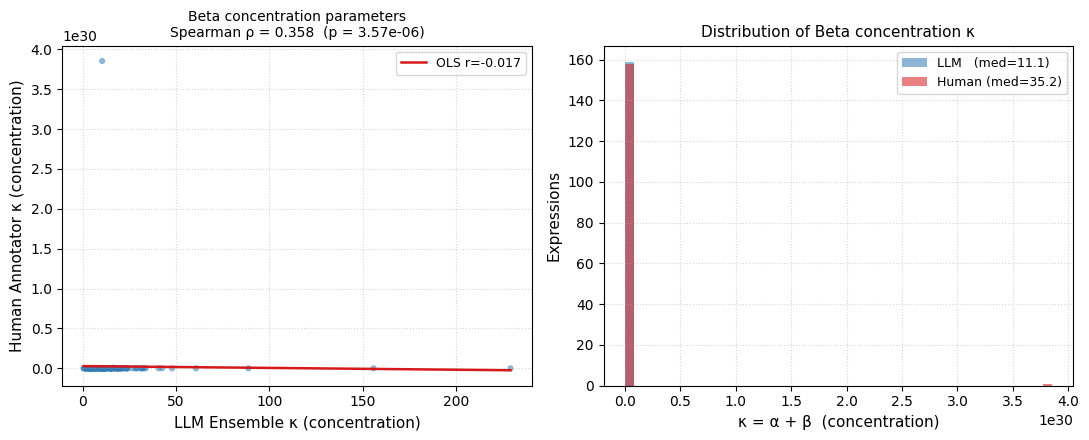

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Scatter κ_LLM vs κ_Human (log scale for legibility)
ax = axes[0]
ax.scatter(k_llm, k_human, s=20, alpha=0.55, color="#2c7bb6", edgecolors="none")
slope, intercept, r_val, p_val, _ = stats.linregress(k_llm, k_human)
xl = np.linspace(k_llm.min(), k_llm.max(), 200)
ax.plot(xl, slope*xl + intercept, color="#d7191c", lw=1.8, label=f"OLS r={r_val:.3f}")
ax.set_xlabel("LLM Ensemble κ (concentration)", fontsize=11)
ax.set_ylabel("Human Annotator κ (concentration)", fontsize=11)
ax.set_title(f"Beta concentration parameters\nSpearman ρ = {sp_k:.3f}  (p = {sp_pk:.2e})",
             fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

# Distribution of κ for LLM vs Human
ax = axes[1]
bins = np.linspace(0, max(k_llm.max(), k_human.max()), 50)
ax.hist(k_llm,   bins=bins, alpha=0.55, color="#2c7bb6", label=f"LLM   (med={np.median(k_llm):.1f})")
ax.hist(k_human, bins=bins, alpha=0.55, color="#d7191c", label=f"Human (med={np.median(k_human):.1f})")
ax.set_xlabel("κ = α + β  (concentration)", fontsize=11)
ax.set_ylabel("Expressions", fontsize=11)
ax.set_title("Distribution of Beta concentration κ", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "beta_concentration.pdf"), bbox_inches="tight", dpi=300)
plt.show()

---
## D. Global Variance-Ratio Tests

Compare total spread across all pooled LLM and human scores.

In [14]:
# Pool ALL scores
all_llm_scores   = np.concatenate(grouped["llm_scores"].values)
all_human_scores = np.concatenate(grouped["human_scores"].values)

var_llm   = np.var(all_llm_scores, ddof=1)
var_human = np.var(all_human_scores, ddof=1)
global_ratio = var_llm / var_human

n_llm_all   = len(all_llm_scores)
n_human_all = len(all_human_scores)

# Classical two-sample F-test for variances
# H0: σ²_LLM = σ²_Human;  F = var_llm / var_human ~ F(n_llm-1, n_human-1)
F_stat = global_ratio
df1, df2 = n_llm_all - 1, n_human_all - 1
p_f = 2 * min(
    stats.f.cdf(F_stat, df1, df2),
    1 - stats.f.cdf(F_stat, df1, df2)
)

print("=== Global Pooled Variances ===")
print(f"  LLM   var = {var_llm:.6f}  (n = {n_llm_all:,})")
print(f"  Human var = {var_human:.6f}  (n = {n_human_all:,})")
print(f"  Ratio σ²_LLM / σ²_Human = {global_ratio:.4f}")
print(f"  F({df1}, {df2}) = {F_stat:.4f},  p = {p_f:.4e}  (two-sided)")
print(f"  Reject H₀ (equal global variances): {p_f < 0.05}")

=== Global Pooled Variances ===
  LLM   var = 0.036491  (n = 14,598)
  Human var = 0.046989  (n = 5,385)
  Ratio σ²_LLM / σ²_Human = 0.7766
  F(14597, 5384) = 0.7766,  p = 3.1372e-30  (two-sided)
  Reject H₀ (equal global variances): True


=== Permutation Test: Global Variance Ratio ===
  Observed ratio : 0.7766  (log = -0.2528)
  Permutation p  : 0.0000e+00  (n_perm = 10,000)
  Reject H₀      : True


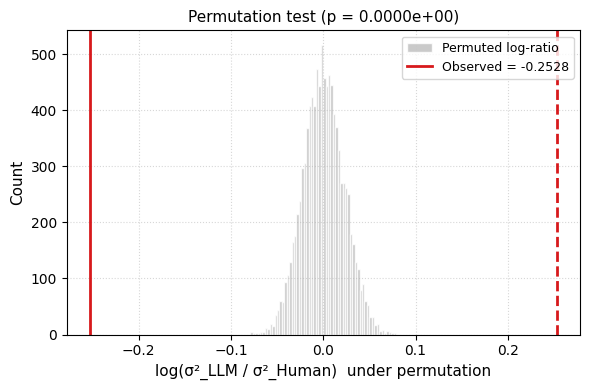

In [15]:
# Permutation test for variance ratio — avoids normality assumption
# Re-label scores as LLM or Human at random, recompute ratio
n_perm     = 10_000
combined   = np.concatenate([all_llm_scores, all_human_scores])
n_llm_pool = len(all_llm_scores)

observed_ratio = global_ratio
perm_ratios = np.empty(n_perm)

for i in range(n_perm):
    perm    = rng.permutation(len(combined))
    a       = combined[perm[:n_llm_pool]]
    b       = combined[perm[n_llm_pool:]]
    perm_ratios[i] = np.var(a, ddof=1) / np.var(b, ddof=1)

p_perm = np.mean(np.abs(np.log(perm_ratios)) >= np.abs(np.log(observed_ratio)))

print("=== Permutation Test: Global Variance Ratio ===")
print(f"  Observed ratio : {observed_ratio:.4f}  (log = {np.log(observed_ratio):+.4f})")
print(f"  Permutation p  : {p_perm:.4e}  (n_perm = {n_perm:,})")
print(f"  Reject H₀      : {p_perm < 0.05}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log(perm_ratios), bins=60, color="#bdbdbd", edgecolor="white",
        alpha=0.8, label="Permuted log-ratio")
ax.axvline(np.log(observed_ratio), color="#d7191c", lw=2,
           label=f"Observed = {np.log(observed_ratio):+.4f}")
ax.axvline(-np.log(observed_ratio), color="#d7191c", lw=2, ls="--")
ax.set_xlabel("log(σ²_LLM / σ²_Human)  under permutation", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"Permutation test (p = {p_perm:.4e})", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "permutation_var_ratio.pdf"), bbox_inches="tight", dpi=300)
plt.show()

---
## E. Summary Table

In [16]:
def fmt_p(p):
    if p < 1e-10: return "< 1e-10"
    if p < 0.001: return f"{p:.2e}"
    return f"{p:.4f}"

lev_sig = (per_expr["levene_p_fdr"]  < 0.05).sum()
flg_sig = (per_expr["fligner_p_fdr"] < 0.05).sum()
ab_sig  = (per_expr["ansari_p_fdr"]  < 0.05).sum()

summary = pd.DataFrame([
    # A. Expression-level variance correlation
    {"Section": "A. Variance correlation (σ)",
     "Test": "Spearman ρ",
     "Statistic": f"{sp_r_std:.4f}", "p-value": fmt_p(sp_p_std)},
    {"Section": "A. Variance correlation (σ)",
     "Test": "Pearson r",
     "Statistic": f"{pe_r_std:.4f}", "p-value": fmt_p(pe_p_std)},
    {"Section": "A. Variance correlation (σ)",
     "Test": "Kendall τ",
     "Statistic": f"{kt_t_std:.4f}", "p-value": fmt_p(kt_p_std)},
    {"Section": "A. Variance correlation (CV)",
     "Test": "Spearman ρ",
     "Statistic": f"{sp_r_cv:.4f}", "p-value": fmt_p(sp_p_cv)},
    {"Section": "A. Variance correlation (CV)",
     "Test": "Pearson r",
     "Statistic": f"{pe_r_cv:.4f}", "p-value": fmt_p(pe_p_cv)},
    {"Section": "A. Variance correlation (CV)",
     "Test": "Kendall τ",
     "Statistic": f"{kt_t_cv:.4f}", "p-value": fmt_p(kt_p_cv)},
    {"Section": "A. Bland–Altman on σ",
     "Test": "Bias (LLM σ − Human σ)",
     "Statistic": f"{bias_std:+.5f}  LoA [{loa_lo:+.5f}, {loa_hi:+.5f}]",
     "p-value": "—"},
    {"Section": "A. Bland–Altman on σ",
     "Test": "% within LoA",
     "Statistic": f"{pct_in:.1f}%", "p-value": "—"},
    {"Section": "A. Wilcoxon on σ",
     "Test": "H₀: median σ_LLM = σ_Human",
     "Statistic": f"W = {wsr_stat:.1f}", "p-value": fmt_p(wsr_p)},
    {"Section": "A. Wilcoxon on CV",
     "Test": "H₀: median CV_LLM = CV_Human",
     "Statistic": f"W = {wsr_cv_stat:.1f}", "p-value": fmt_p(wsr_cv_p)},
    # B. Per-expression scale tests
    {"Section": "B. Per-expression scale (FDR)",
     "Test": "Levene's test (BH α=0.05)",
     "Statistic": f"{lev_sig}/{n_total} ({lev_sig/n_total*100:.1f}%) sig.",
     "p-value": "—"},
    {"Section": "B. Per-expression scale (FDR)",
     "Test": "Fligner–Killeen test (BH α=0.05)",
     "Statistic": f"{flg_sig}/{n_total} ({flg_sig/n_total*100:.1f}%) sig.",
     "p-value": "—"},
    {"Section": "B. Per-expression scale (FDR)",
     "Test": "Ansari–Bradley test (BH α=0.05)",
     "Statistic": f"{ab_sig}/{n_total} ({ab_sig/n_total*100:.1f}%) sig.",
     "p-value": "—"},
    {"Section": "B. Variance ratio",
     "Test": "Median σ²_LLM / σ²_Human",
     "Statistic": f"{per_expr['var_ratio'].median():.4f}",
     "p-value": "—"},
    {"Section": "B. Variance ratio",
     "Test": "% within [0.5, 2.0] ratio",
     "Statistic": f"{pct_within2x:.1f}%",
     "p-value": "—"},
    # C. Beta concentration
    {"Section": "C. Beta concentration κ",
     "Test": "Spearman ρ (κ_LLM vs κ_Human)",
     "Statistic": f"{sp_k:.4f}", "p-value": fmt_p(sp_pk)},
    {"Section": "C. Beta concentration κ",
     "Test": "Pearson r",
     "Statistic": f"{pe_k:.4f}", "p-value": fmt_p(pe_pk)},
    {"Section": "C. Beta concentration κ",
     "Test": "Kendall τ",
     "Statistic": f"{kt_k:.4f}", "p-value": fmt_p(kt_pk)},
    {"Section": "C. Beta concentration κ",
     "Test": "Wilcoxon (H₀: κ_LLM = κ_Human)",
     "Statistic": f"W = {wsr_k:.1f}", "p-value": fmt_p(wsr_pk)},
    {"Section": "C. Beta concentration κ",
     "Test": "Median κ_LLM / κ_Human",
     "Statistic": f"LLM={np.median(k_llm):.2f}  Human={np.median(k_human):.2f}",
     "p-value": "—"},
    # D. Global
    {"Section": "D. Global variance",
     "Test": "F-test (pooled, classical)",
     "Statistic": f"F = {F_stat:.4f}  (ratio = {global_ratio:.4f})",
     "p-value": fmt_p(p_f)},
    {"Section": "D. Global variance",
     "Test": "Permutation test (n=10 000)",
     "Statistic": f"ratio = {observed_ratio:.4f}",
     "p-value": fmt_p(p_perm)},
])

summary = summary.set_index(["Section", "Test"])
print("=== Full Variance / Concentration Alignment Summary ===")
summary

=== Full Variance / Concentration Alignment Summary ===


Statistic  \
Section                       Test                                                                   
A. Variance correlation (σ)   Spearman ρ                                                    0.5560   
                              Pearson r                                                     0.6975   
                              Kendall τ                                                     0.4078   
A. Variance correlation (CV)  Spearman ρ                                                    0.7211   
                              Pearson r                                                     0.6111   
                              Kendall τ                                                     0.5459   
A. Bland–Altman on σ          Bias (LLM σ − Human σ)            +0.02266  LoA [-0.09531, +0.14064]   
                              % within LoA                                                   95.6%   
A. Wilcoxon on σ              H₀: median σ_LLM = σ_Human                                W = 3027.0   
A. Wilcoxon on CV             H₀: median CV_LLM = CV_Human                              W = 4746.0   
B. Per-expression scale (FDR) Levene's test (BH α=0.05)                        32/159 (20.1%) sig.   
                              Fligner–Killeen test (BH α=0.05)                 32/159 (20.1%) sig.   
                              Ansari–Bradley test (BH α=0.05)                  53/159 (33.3%) sig.   
B. Variance ratio             Median σ²_LLM / σ²_Human                                      1.8970   
                              % within [0.5, 2.0] ratio                                      43.7%   
C. Beta concentration κ       Spearman ρ (κ_LLM vs κ_Human)                                 0.3581   
                              Pearson r                                                    -0.0174   
                              Kendall τ                                                     0.2529   
                              Wilcoxon (H₀: κ_LLM = κ_Human)                            W = 1250.0   
                              Median κ_LLM / κ_Human                        LLM=11.10  Human=35.19   
D. Global variance            F-test (pooled, classical)              F = 0.7766  (ratio = 0.7766)   
                              Permutation test (n=10 000)                           ratio = 0.7766   

                                                                 p-value  
Section                       Test                                        
A. Variance correlation (σ)   Spearman ρ                         < 1e-10  
                              Pearson r                          < 1e-10  
                              Kendall τ                          < 1e-10  
A. Variance correlation (CV)  Spearman ρ                         < 1e-10  
                              Pearson r                          < 1e-10  
                              Kendall τ                          < 1e-10  
A. Bland–Altman on σ          Bias (LLM σ − Human σ)                   —  
                              % within LoA                             —  
A. Wilcoxon on σ              H₀: median σ_LLM = σ_Human        9.94e-09  
A. Wilcoxon on CV             H₀: median CV_LLM = CV_Human        0.0055  
B. Per-expression scale (FDR) Levene's test (BH α=0.05)                —  
                              Fligner–Killeen test (BH α=0.05)         —  
                              Ansari–Bradley test (BH α=0.05)          —  
B. Variance ratio             Median σ²_LLM / σ²_Human                 —  
                              % within [0.5, 2.0] ratio                —  
C. Beta concentration κ       Spearman ρ (κ_LLM vs κ_Human)     3.57e-06  
                              Pearson r                           0.8276  
                              Kendall τ                         2.23e-06  
                              Wilcoxon (H₀: κ_LLM = κ_Human)     < 1e-10  
                              Median κ_LLM / κ_Human             

## Save Results

In [17]:
summary.to_csv(os.path.join(SAVE_DIR, "variance_alignment_summary.csv"))
per_expr.to_csv(os.path.join(SAVE_DIR, "per_expression_scale_tests.csv"), index=False)
kappa_df.to_csv(os.path.join(SAVE_DIR, "beta_concentration_fits.csv"), index=False)
grouped[["expression","n_items","llm_n","human_n",
         "llm_std","human_std","llm_cv","human_cv",
         "llm_var","human_var"]].to_csv(
    os.path.join(SAVE_DIR, "expression_variance_stats.csv"), index=False)

print("Saved:")
for fname in [
    "variance_alignment_summary.csv",
    "per_expression_scale_tests.csv",
    "beta_concentration_fits.csv",
    "expression_variance_stats.csv",
]:
    path = os.path.join(SAVE_DIR, fname)
    print(f"  {path}  ({os.path.getsize(path):,} bytes)")

print("\nFigures:")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"  {os.path.join(FIG_DIR, f)}")

Saved:
  /home/ivan/lm-confidence-evaluation-harness/rebuttal/llm-human-alignment-var/variance_alignment_summary.csv  (1,497 bytes)
  /home/ivan/lm-confidence-evaluation-harness/rebuttal/llm-human-alignment-var/per_expression_scale_tests.csv  (38,316 bytes)
  /home/ivan/lm-confidence-evaluation-harness/rebuttal/llm-human-alignment-var/beta_concentration_fits.csv  (19,768 bytes)
  /home/ivan/lm-confidence-evaluation-harness/rebuttal/llm-human-alignment-var/expression_variance_stats.csv  (22,473 bytes)

Figures:
  /home/ivan/lm-confidence-evaluation-harness/rebuttal/llm-human-alignment-var/figs/beta_concentration.pdf
  /home/ivan/lm-confidence-evaluation-harness/rebuttal/llm-human-alignment-var/figs/bland_altman_std.pdf
  /home/ivan/lm-confidence-evaluation-harness/rebuttal/llm-human-alignment-var/figs/permutation_var_ratio.pdf
  /home/ivan/lm-confidence-evaluation-harness/rebuttal/llm-human-alignment-var/figs/scale_test_pvals.pdf
  /home/ivan/lm-confidence-evaluation-harness/rebuttal/ll